# Причинный анализ предсказательных моделей для Индекса Московской биржи

Этот ноутбук реализует эмпирическую часть курсовой работы и включает:

- загрузку данных из MOEX и Yahoo Finance,
- построение недельного датасета,
- описательный анализ,
- baseline-модели,
- оценку причинных эффектов через Double Machine Learning,
- сравнение моделей,
- анализ гетерогенности,
- анализ по подпериодам,
- проверки устойчивости результатов.

## Импорт библиотек

In [ ]:
!pip install yfinance econml requests statsmodels matplotlib pandas numpy scikit-learn pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.9 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import requests
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller

from econml.dml import LinearDML

from pyvis.network import Network
from IPython.display import HTML, display

## 1. Загрузка данных

Спецификация:

- **Y**: недельная доходность IMOEX;
- **T**:
  - нефтяной шок: недельное изменение цены Brent,
  - валютный шок: недельное изменение курса USD/RUB;
- **X**: контрольные переменные:
  - лаг доходности IMOEX,
  - лаг Brent,
  - лаг USD/RUB,
  - доходность S&P 500,
  - индекс VIX.

Период исследования: **2014–2026 годы**.  
Частота данных: **недельная**.

### 1.1 Загрузка данных

Сначала загружаем индекс IMOEX с официального API Московской биржи.

In [ ]:
def load_moex_imoex(start_date="2014-01-01", end_date="2026-04-13"):
    url = "https://iss.moex.com/iss/history/engines/stock/markets/index/securities/IMOEX.json"
    start = 0
    frames = []

    while True:
        params = {
            "from": start_date,
            "till": end_date,
            "start": start
        }
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        js = r.json()

        cols = js["history"]["columns"]
        data = js["history"]["data"]

        if not data:
            break

        df = pd.DataFrame(data, columns=cols)
        frames.append(df)

        if len(df) < 100:
            break

        start += 100

    imoex = pd.concat(frames, ignore_index=True)
    imoex["TRADEDATE"] = pd.to_datetime(imoex["TRADEDATE"])
    imoex = imoex[["TRADEDATE", "CLOSE"]].rename(columns={
        "TRADEDATE": "Date",
        "CLOSE": "IMOEX"
    })
    imoex = imoex.dropna().sort_values("Date").set_index("Date")

    return imoex

In [ ]:
imoex = load_moex_imoex()

print("Первые строки IMOEX:")
display(imoex.head())

print("Последние строки IMOEX:")
display(imoex.tail())

print("Размер таблицы:", imoex.shape)

Первые строки IMOEX:


,IMOEX
Date,
2014-01-06,1466.15
2014-01-08,1462.67
2014-01-09,1465.14
2014-01-10,1469.19
2014-01-13,1477.56


Последние строки IMOEX:


,IMOEX
Date,
2026-04-07,2797.24
2026-04-08,2765.06
2026-04-09,2733.40
2026-04-10,2725.39
2026-04-13,2722.69


Размер таблицы: (3083, 1)


### 1.2. Загрузка Brent, USD/RUB, S&P 500 и VIX из Yahoo Finance

In [ ]:
tickers = {
    "Brent": "BZ=F",
    "USD_RUB": "RUB=X",
    "SP500": "^GSPC",
    "VIX": "^VIX"
}

raw = yf.download(
    list(tickers.values()),
    start="2014-01-01",
    interval="1d",
    auto_adjust=False,
    progress=True
)

data_yahoo = raw["Close"].copy()
data_yahoo.columns = tickers.keys()

print("\nПервые строки данных:")
display(data_yahoo.head())

print("Последние строки данных:")
display(data_yahoo.tail())

print("Размер таблицы:", data_yahoo.shape)

[*********************100%***********************]  4 of 4 completed



Первые строки данных:


,Brent,USD_RUB,SP500,VIX
Date,,,,
2014-01-01,NaN,32.683201,NaN,NaN
2014-01-02,107.779999,32.706001,1831.979980,14.23
2014-01-03,106.889999,33.095200,1831.369995,13.76
2014-01-06,106.730003,33.165001,1826.770020,13.55
2014-01-07,107.349998,33.143200,1837.880005,12.92


Последние строки данных:


,Brent,USD_RUB,SP500,VIX
Date,,,,
2026-04-23,105.070000,75.097450,7108.399902,19.309999
2026-04-24,105.330002,75.872162,7165.080078,18.709999
2026-04-27,108.230003,74.525246,7173.910156,18.020000
2026-04-28,111.260002,74.866417,7138.799805,17.830000
2026-04-29,109.279999,75.040001,7123.180176,18.400000


Размер таблицы: (3212, 4)


## 2. Приведение к недельной частоте

В качестве недельного значения беру последнее доступное наблюдение за неделю (в пятницу, т.к. в выходные дни биржи закрыты).

In [ ]:
imoex_w = imoex.resample("W-FRI").last()
yahoo_w = data_yahoo.resample("W-FRI").last()

data = imoex_w.join(yahoo_w, how="inner")

print("Первые строки недельного датасета:")
display(data.head(10))

print("\n")

print("Последние строки недельного датасета:")
display(data.tail(10))

Первые строки недельного датасета:


,IMOEX,Brent,USD_RUB,SP500,VIX
Date,,,,,
2014-01-10,1469.19,107.250000,33.147900,1842.369995,12.140000
2014-01-17,1486.88,107.059998,33.389198,1838.699951,12.440000
2014-01-24,1494.58,107.879997,34.065201,1790.290039,18.139999
2014-01-31,1454.45,106.400002,34.903301,1782.589966,18.410000
2014-02-07,1478.48,109.570000,34.662102,1797.020020,15.290000
2014-02-14,1496.18,108.730003,35.079399,1838.630005,13.570000
2014-02-21,1487.64,109.849998,35.719799,1836.250000,14.680000
2014-02-28,1444.71,109.070000,35.990898,1859.449951,14.000000
2014-03-07,1339.36,109.000000,36.083099,1878.040039,14.110000




Последние строки недельного датасета:


,IMOEX,Brent,USD_RUB,SP500,VIX
Date,,,,,
2026-02-13,2776.34,67.750000,77.230354,6836.169922,20.600000
2026-02-20,2780.60,71.760002,76.746536,6909.509766,19.090000
2026-02-27,2799.14,72.480003,76.871536,6878.879883,19.860001
2026-03-06,2854.11,92.690002,78.661011,6740.020020,29.490000
2026-03-13,2871.86,103.139999,79.497536,6632.189941,27.190001
2026-03-20,2864.89,112.190002,86.146149,6506.479980,26.780001
2026-03-27,2789.61,112.570000,81.371475,6368.850098,31.049999
2026-04-03,2760.70,109.029999,80.182648,6582.689941,23.870001
2026-04-10,2725.39,95.199997,77.619156,6816.890137,19.230000


Проверка структуры и пропусков:

In [ ]:
print("Размер итоговой таблицы:", data.shape)
print("\nПропуски по столбцам:")
print(data.isna().sum())

print("\nИнформация о таблице:")
print(data.info())

Размер итоговой таблицы: (641, 5)

Пропуски по столбцам:
IMOEX      3
Brent      0
USD_RUB    0
SP500      0
VIX        0
dtype: int64

Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 641 entries, 2014-01-10 to 2026-04-17
Freq: W-FRI
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   IMOEX    638 non-null    float64
 1   Brent    641 non-null    float64
 2   USD_RUB  641 non-null    float64
 3   SP500    641 non-null    float64
 4   VIX      641 non-null    float64
dtypes: float64(5)
memory usage: 30.0 KB
None


Недельный датасет имеет 641 наблюдение. Пропуски есть только у IMOEX (3 значения), их удалю. В целом данные хорошие и готовы для дальнейшего анализа.


## 3. Подготовка рабочего датасета

На этом этапе:
- удаляются остаточные пропуски,
- рассчитываются логарифмические доходности,
- формируется таблица для моделирования.

In [ ]:
df = data.dropna().copy()

model_df = pd.DataFrame(index=df.index)

model_df["imoex_ret"] = np.log(df["IMOEX"] / df["IMOEX"].shift(1))
model_df["brent_ret"] = np.log(df["Brent"] / df["Brent"].shift(1))
model_df["usdrub_ret"] = np.log(df["USD_RUB"] / df["USD_RUB"].shift(1))
model_df["sp500_ret"] = np.log(df["SP500"] / df["SP500"].shift(1))

# VIX оставляем в уровнях
model_df["vix"] = df["VIX"]

model_df = model_df.dropna()

display(model_df.head(10))
print("Размер рабочего датасета:", model_df.shape)

,imoex_ret,brent_ret,usdrub_ret,sp500_ret,vix
Date,,,,,
2014-01-17,0.011969,-0.001773,0.007253,-0.001994,12.440000
2014-01-24,0.005165,0.007630,0.020044,-0.026681,18.139999
2014-01-31,-0.027217,-0.013814,0.024305,-0.004310,18.410000
2014-02-07,0.016387,0.029358,-0.006934,0.008062,15.290000
2014-02-14,0.011901,-0.007696,0.011967,0.022891,13.570000
2014-02-21,-0.005724,0.010248,0.018091,-0.001295,14.680000
2014-02-28,-0.029282,-0.007126,0.007561,0.012555,14.000000
2014-03-07,-0.075717,-0.000642,0.002559,0.009948,14.110000
2014-03-14,-0.079155,-0.003953,0.011794,-0.019849,17.820000


Размер рабочего датасета: (637, 5)


### Построение лагов (значение переменных в прошлом периоде):

In [ ]:
model_df["imoex_ret_lag1"] = model_df["imoex_ret"].shift(1)
model_df["brent_ret_lag1"] = model_df["brent_ret"].shift(1)
model_df["usdrub_ret_lag1"] = model_df["usdrub_ret"].shift(1)

model_df = model_df.dropna()

display(model_df.head(10))
print("Размер после построения лагов:", model_df.shape)
print("\nПропуски:")
print(model_df.isna().sum())

,imoex_ret,brent_ret,usdrub_ret,sp500_ret,vix,imoex_ret_lag1,brent_ret_lag1,usdrub_ret_lag1
Date,,,,,,,,
2014-01-24,0.005165,0.007630,0.020044,-0.026681,18.139999,0.011969,-0.001773,0.007253
2014-01-31,-0.027217,-0.013814,0.024305,-0.004310,18.410000,0.005165,0.007630,0.020044
2014-02-07,0.016387,0.029358,-0.006934,0.008062,15.290000,-0.027217,-0.013814,0.024305
2014-02-14,0.011901,-0.007696,0.011967,0.022891,13.570000,0.016387,0.029358,-0.006934
2014-02-21,-0.005724,0.010248,0.018091,-0.001295,14.680000,0.011901,-0.007696,0.011967
2014-02-28,-0.029282,-0.007126,0.007561,0.012555,14.000000,-0.005724,0.010248,0.018091
2014-03-07,-0.075717,-0.000642,0.002559,0.009948,14.110000,-0.029282,-0.007126,0.007561
2014-03-14,-0.079155,-0.003953,0.011794,-0.019849,17.820000,-0.075717,-0.000642,0.002559
2014-03-21,0.054958,-0.015314,-0.006132,0.013696,15.000000,-0.079155,-0.003953,0.011794


Размер после построения лагов: (636, 8)

Пропуски:
imoex_ret          0
brent_ret          0
usdrub_ret         0
sp500_ret          0
vix                0
imoex_ret_lag1     0
brent_ret_lag1     0
usdrub_ret_lag1    0
dtype: int64


Добавляет лаги, которые нужны как контроли:

- прошлую доходность IMOEX,
- прошлое изменение Brent,
- прошлое изменение USD/RUB.

## 4. Разведочный анализ


Теперь посмотрим на графики исходных рядов.

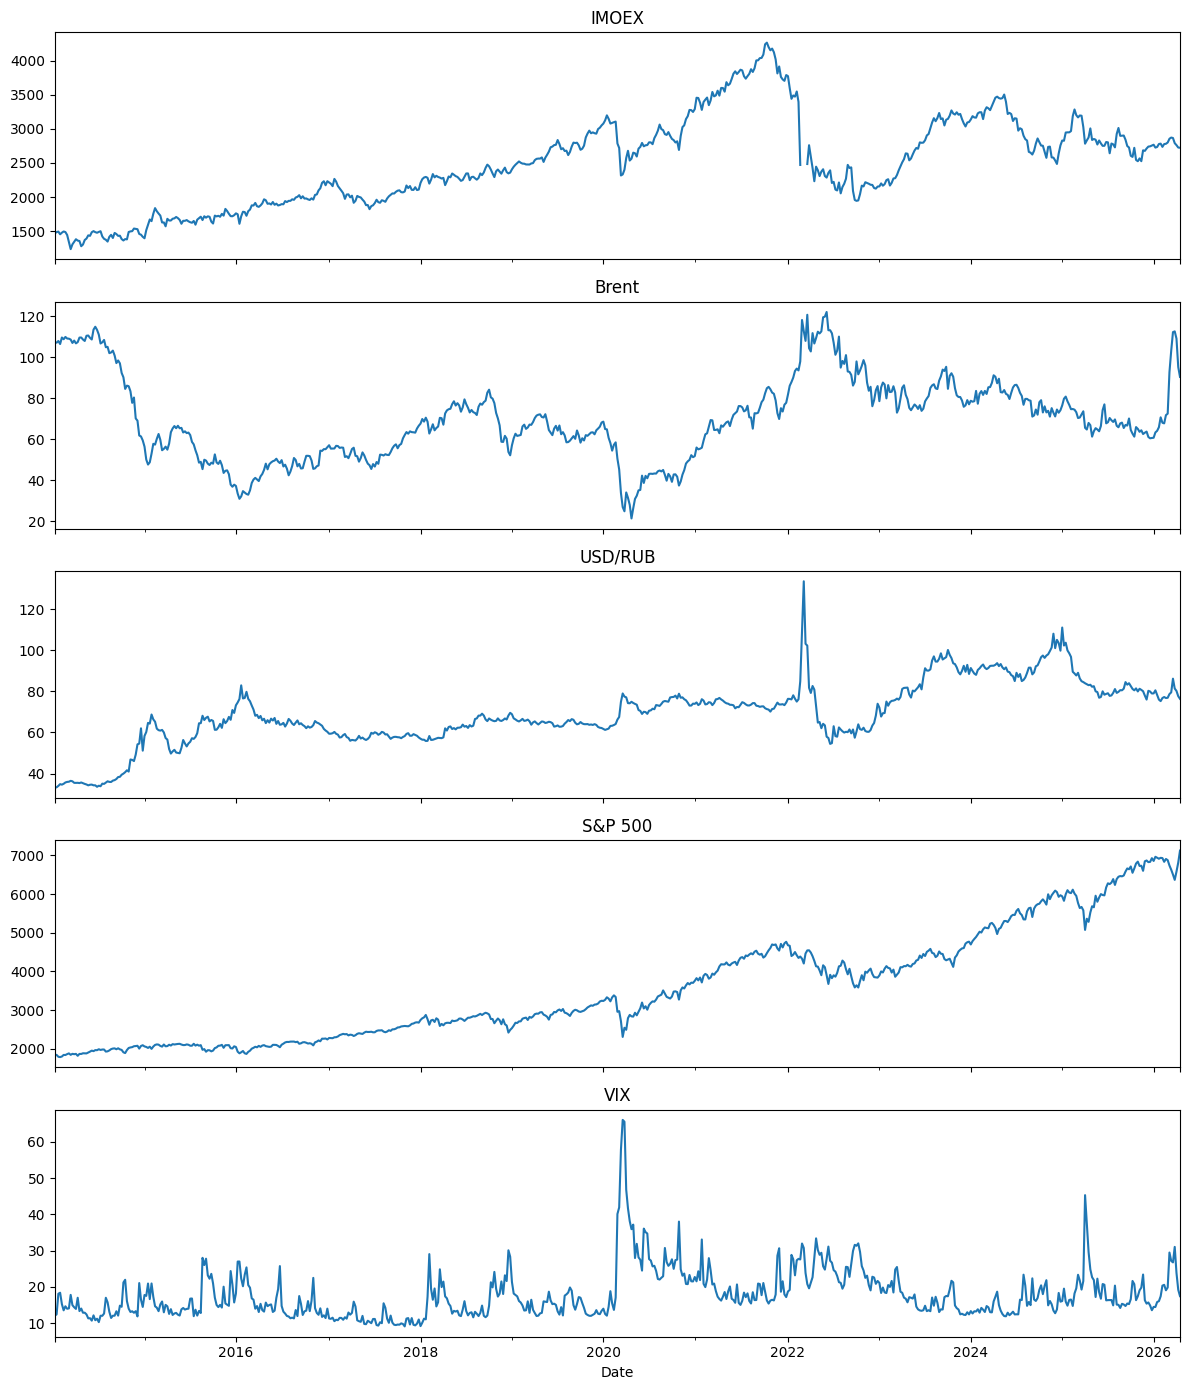

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

data["IMOEX"].plot(ax=axes[0], title="IMOEX")
data["Brent"].plot(ax=axes[1], title="Brent")
data["USD_RUB"].plot(ax=axes[2], title="USD/RUB")
data["SP500"].plot(ax=axes[3], title="S&P 500")
data["VIX"].plot(ax=axes[4], title="VIX")

plt.tight_layout()
plt.show()

- IMOEX и S&P 500 имеют долгосрочный рост с падениями в кризисные периоды.
- Цены на нефть и курс USD/RUB имеют более высокую волатильность.
- Индекс VIX резко возрастает в периоды рыночной нестабильности.

Графики доходностей:

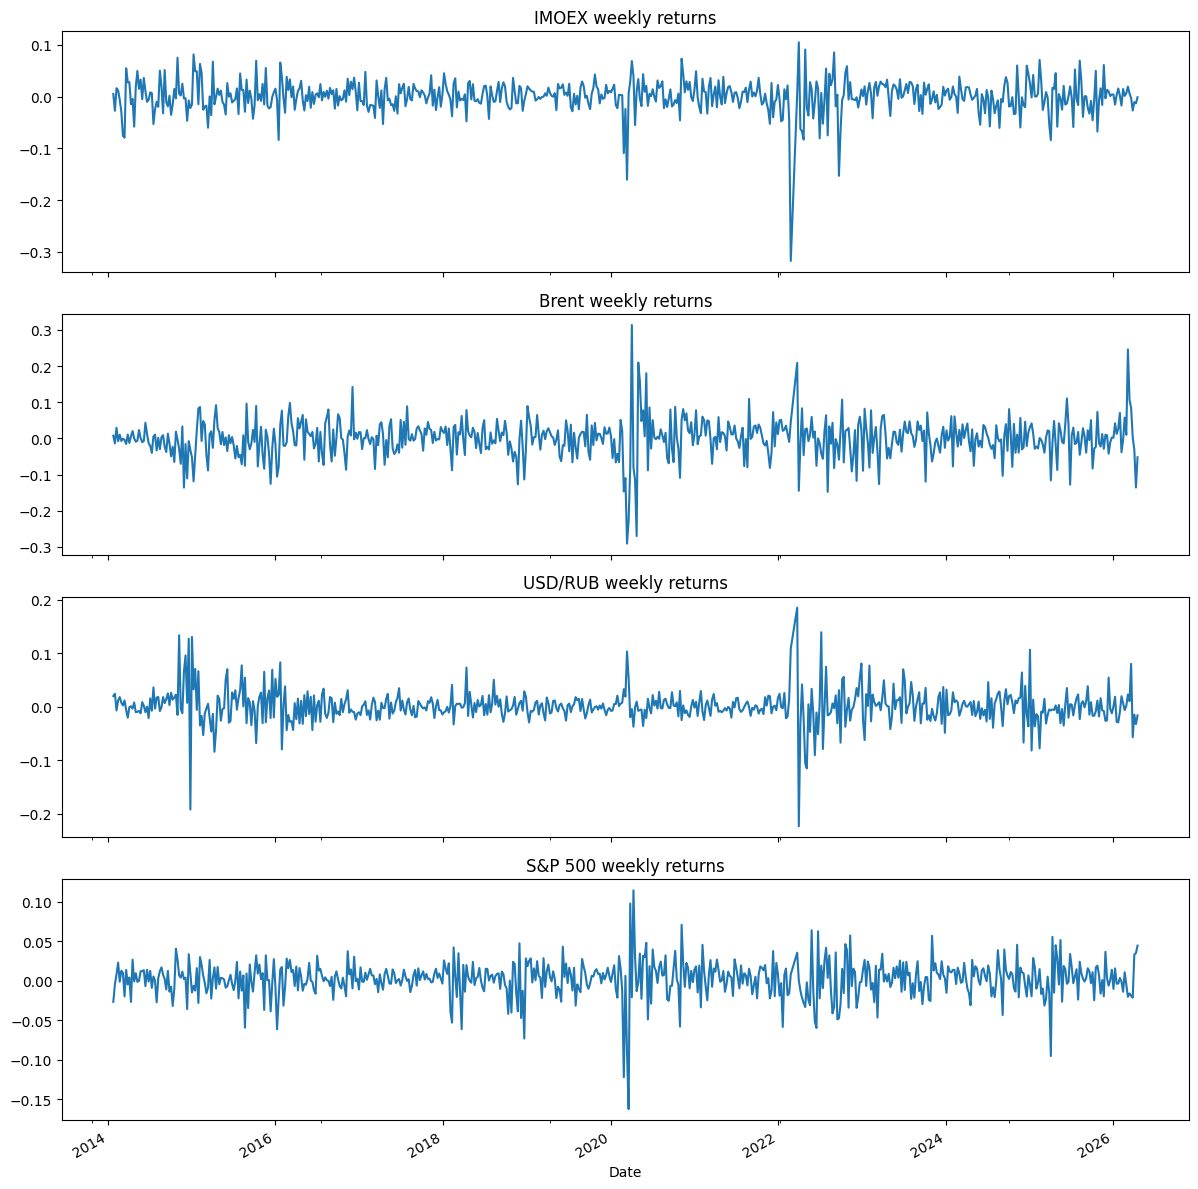

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

model_df["imoex_ret"].plot(ax=axes[0], title="IMOEX weekly returns")
model_df["brent_ret"].plot(ax=axes[1], title="Brent weekly returns")
model_df["usdrub_ret"].plot(ax=axes[2], title="USD/RUB weekly returns")
model_df["sp500_ret"].plot(ax=axes[3], title="S&P 500 weekly returns")

plt.tight_layout()
plt.show()

- Доходности всех рядов колеблются вокруг нуля, что соответствует их стационарной природе.
- Наблюдаются резкие всплески волатильности в кризисные периоды, особенно в 2020 и 2022 годах.
- Наиболее сильные колебания характерны для нефти и курса USD/RUB, в то же время S&P 500 выглядит более стабильным.

#### Корреляции:

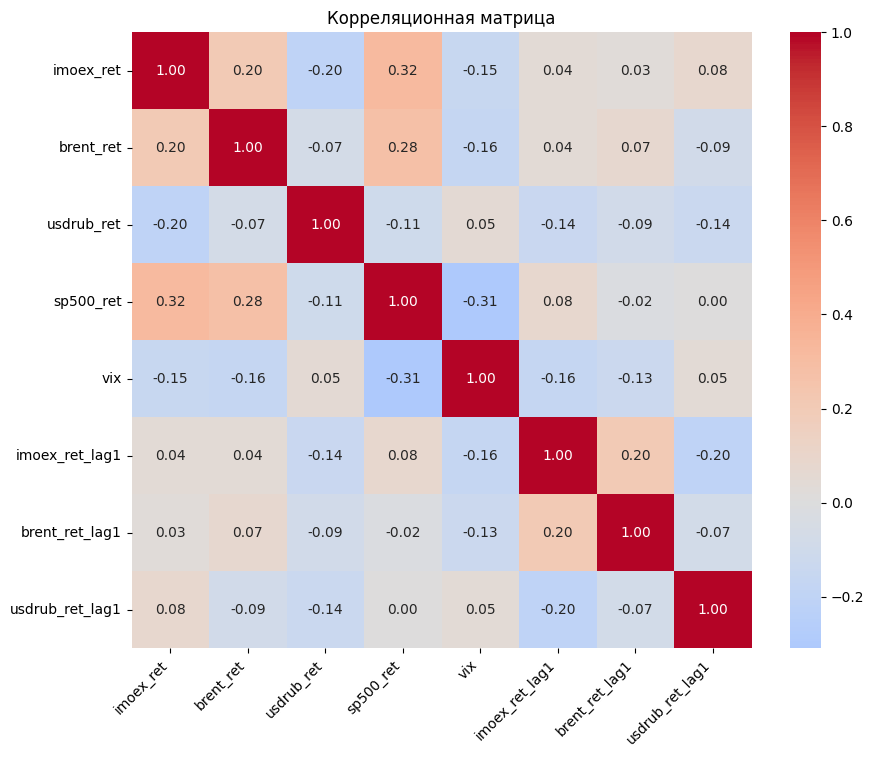

In [ ]:
corr = model_df[[
    "imoex_ret",
    "brent_ret",
    "usdrub_ret",
    "sp500_ret",
    "vix",
    "imoex_ret_lag1",
    "brent_ret_lag1",
    "usdrub_ret_lag1"
]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.xticks(rotation=45, ha="right")
plt.title("Корреляционная матрица")
plt.show()


- Доходность IMOEX положительно связана с нефтью, глобальным рынком (S&P 500) и отрицательно — с курсом USD/RUB и индексом VIX.
- При этом зависимости умеренные, что указывает на наличие влияния других факторов.
- Лаговые переменные имеют слабую корреляцию с текущими значениями, что подтверждает необходимость их включения как контрольных переменных.

#### Описательная статистика

In [ ]:
display(model_df.describe())

,imoex_ret,brent_ret,usdrub_ret,sp500_ret,vix,imoex_ret_lag1,brent_ret_lag1,usdrub_ret_lag1
count,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000
mean,0.000951,-0.000266,0.001301,0.002130,17.814748,0.000972,-0.000187,0.001338
std,0.030989,0.052646,0.031096,0.022864,6.741114,0.030992,0.052606,0.031089
min,-0.317393,-0.290706,-0.223841,-0.162279,9.140000,-0.317393,-0.290706,-0.223841
25%,-0.012958,-0.025106,-0.012280,-0.008700,13.297500,-0.012958,-0.024870,-0.012267
50%,0.001731,0.002462,0.000138,0.003443,16.125000,0.001772,0.002462,0.000181
75%,0.017133,0.025468,0.013875,0.014661,20.809999,0.017133,0.025468,0.013875
max,0.105178,0.313519,0.185428,0.114237,66.040001,0.105178,0.313519,0.185428


Доходности всех переменных в среднем близки к нулю, что типично для финансовых рядов. При этом есть высокая волатильность (значение std) у нефти и курса рубля. Индекс VIX показывает уровень рыночного риска и имеет более стабильное распределение.


## 5. Базовые модели

Сначала оцениваем простая линейная модель как базовую.

In [ ]:
Y = model_df["imoex_ret"]

X_oil = model_df[[
    "brent_ret",
    "imoex_ret_lag1",
    "brent_ret_lag1",
    "usdrub_ret_lag1",
    "sp500_ret",
    "vix"
]]

lin_model_oil = LinearRegression()
lin_model_oil.fit(X_oil, Y)

oil_baseline_coefs = pd.Series(lin_model_oil.coef_, index=X_oil.columns)
display(oil_baseline_coefs)

,0
brent_ret,0.075885
imoex_ret_lag1,0.027150
brent_ret_lag1,0.012902
usdrub_ret_lag1,0.098972
sp500_ret,0.363192
vix,-0.000183


В линейной модели наибольшее влияние на доходность IMOEX оказывает глобальный рынок (S&P 500).
Нефть имеет положительное, но умеренное влияние, а лаги и индекс VIX оказывают слабый эффект.

Базовая модель для валютного шока:

In [ ]:
X_fx = model_df[[
    "usdrub_ret",
    "imoex_ret_lag1",
    "brent_ret_lag1",
    "usdrub_ret_lag1",
    "sp500_ret",
    "vix"
]]

lin_model_fx = LinearRegression()
lin_model_fx.fit(X_fx, Y)

fx_baseline_coefs = pd.Series(lin_model_fx.coef_, index=X_fx.columns)
display(fx_baseline_coefs)

,0
usdrub_ret,-0.159209
imoex_ret_lag1,-0.000538
brent_ret_lag1,0.010574
usdrub_ret_lag1,0.060825
sp500_ret,0.387788
vix,-0.000232


- Валютный шок оказывает отрицательное влияние на доходность IMOEX, что соответствует экономической логике (ослабление рубля связано с падением рынка).
- Наибольшее влияние также оказывает S&P 500
- Остальные факторы имеют слабый эффект.

## 6. Причинная модель: Double Machine Learning


Метод Double Machine Learning позволяет оценивать причинные эффекты,
учитывая большое число контрольных переменных и избегая смещения оценок.

### Сначала оцениваем причинный эффект нефтяного шока.

In [ ]:
Y_np = model_df["imoex_ret"].values
T_oil = model_df["brent_ret"].values

X_np = model_df[[
    "imoex_ret_lag1",
    "brent_ret_lag1",
    "usdrub_ret_lag1",
    "sp500_ret",
    "vix"
]].values

Оценка среднего причинного эффекта нефтяного шока:

Здесь DML-модель:

- отдельно учит модель результата,
- отдельно учит модель воздействия,
- затем оценивает причинный эффект.

In [ ]:
dml_oil = LinearDML(
    model_y=RandomForestRegressor(random_state=42),
    model_t=RandomForestRegressor(random_state=42),
    random_state=42
)

dml_oil.fit(Y_np, T_oil, X=X_np)

Результаты:

In [ ]:
ate_oil = dml_oil.ate(X_np)
ci_oil = dml_oil.ate_interval(X_np)

print("ATE (oil):", ate_oil)
print("95% CI (oil):", ci_oil)

ATE (oil): 0.06557824614157179
95% CI (oil): (np.float64(0.016264095186593074), np.float64(0.1148923970965505))


- Нефтяной шок оказывает положительное влияние на доходность IMOEX.
- Оценка среднего причинного эффекта (ATE) составляет около 0.065.
- Доверительный интервал не включает ноль, значит есть статистическая значимость эффекта.

### Теперь посмотрим на валютный шок:

In [ ]:
T_fx = model_df["usdrub_ret"].values

dml_fx = LinearDML(
    model_y=RandomForestRegressor(random_state=42),
    model_t=RandomForestRegressor(random_state=42),
    random_state=42
)

dml_fx.fit(Y_np, T_fx, X=X_np)

Результаты валютного шока:

In [ ]:
ate_fx = dml_fx.ate(X_np)
ci_fx = dml_fx.ate_interval(X_np)

print("ATE (fx):", ate_fx)
print("95% CI (fx):", ci_fx)

ATE (fx): -0.1370375920570733
95% CI (fx): (np.float64(-0.24206739666480015), np.float64(-0.03200778744934647))


- Валютный шок оказывает отрицательное влияние на доходность IMOEX.
- Оценка среднего причинного эффекта (ATE) составляет около -0.137.
- Доверительный интервал не включает ноль, значит есть статистическая значимость эффекта.

## 7. Сравнение базовых моделей и DML

In [ ]:
comparison = pd.DataFrame({
    "model": ["Linear (oil)", "DML (oil)", "Linear (fx)", "DML (fx)"],
    "effect": [
        oil_baseline_coefs["brent_ret"],
        ate_oil,
        fx_baseline_coefs["usdrub_ret"],
        ate_fx
    ]
})

display(comparison)

,model,effect
0,Linear (oil),0.075885
1,DML (oil),0.065578
2,Linear (fx),-0.159209
3,DML (fx),-0.137038


Оценки, полученные с помощью линейной модели и DML, различаются, что указывает на возможное смещение в простой регрессии.
DML позволяет более корректно учитывать влияние контрольных переменных.

## 8. Гетерогенность эффектов

Гетерогенность означает, что влияние факторов на доходность IMOEX не является одинаковым во все периоды времени и зависит от состояния рынка.

In [ ]:
te_oil = dml_oil.effect(X_np)
te_fx = dml_fx.effect(X_np)

print("Средний oil effect:", np.mean(te_oil))
print("Std oil effect:", np.std(te_oil))

print("Средний fx effect:", np.mean(te_fx))
print("Std fx effect:", np.std(te_fx))

Средний oil effect: 0.06557824614157179
Std oil effect: 0.07547939860953341
Средний fx effect: -0.1370375920570733
Std fx effect: 0.2001520159018471


Эффекты не постоянны и меняются во времени, что указывает на наличие гетерогенности и зависимость реакции рынка от текущих условий.

График индивидуальных ээффектов:

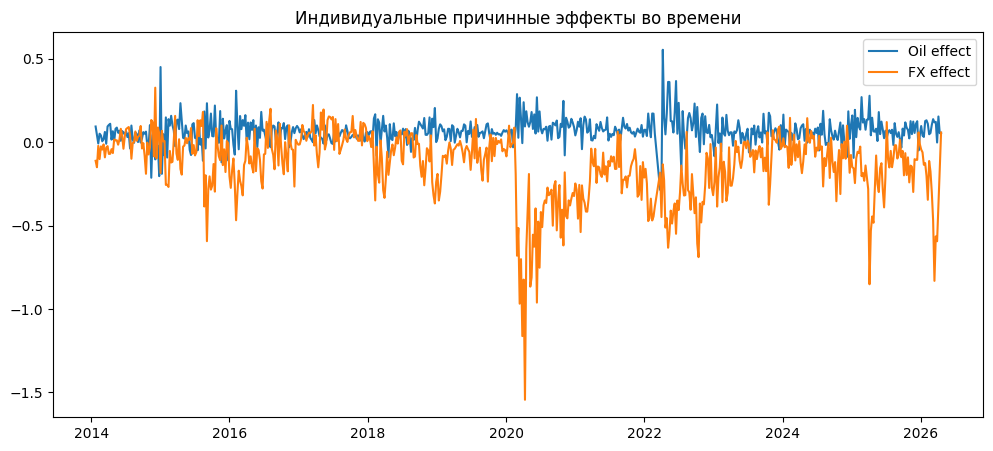

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(model_df.index, te_oil, label="Oil effect")
plt.plot(model_df.index, te_fx, label="FX effect")
plt.legend()
plt.title("Индивидуальные причинные эффекты во времени")
plt.show()

График показывает, что влияние факторов существенно меняется во времени.

Нефтяной эффект в основном остаётся положительным и относительно стабильным, тогда как валютный эффект более волатильный и часто принимает отрицательные значения, особенно в периоды кризисов.

## 9. Анализ по подпериодам

Далее проверим, меняются ли эффекты в зависимости от периода наблюдения.

Посмотрим на периоды до и после 2022 года:

In [ ]:
pre_2022 = model_df.loc[model_df.index < "2022-01-01"].copy()
post_2022 = model_df.loc[model_df.index >= "2022-01-01"].copy()

print("До 2022:", pre_2022.shape)
print("После 2022:", post_2022.shape)

До 2022: (415, 8)
После 2022: (221, 8)


Функция оценки DML на подвыборке:

In [ ]:
def estimate_dml_effect(df, treatment_col):
    Y_sub = df["imoex_ret"].values
    T_sub = df[treatment_col].values
    X_sub = df[[
        "imoex_ret_lag1",
        "brent_ret_lag1",
        "usdrub_ret_lag1",
        "sp500_ret",
        "vix"
    ]].values

    model = LinearDML(
        model_y=RandomForestRegressor(random_state=42),
        model_t=RandomForestRegressor(random_state=42),
        random_state=42
    )
    model.fit(Y_sub, T_sub, X=X_sub)
    ate = model.ate(X_sub)
    ci = model.ate_interval(X_sub)
    return ate, ci

Эффекты:

In [ ]:
oil_pre, oil_pre_ci = estimate_dml_effect(pre_2022, "brent_ret")
oil_post, oil_post_ci = estimate_dml_effect(post_2022, "brent_ret")

fx_pre, fx_pre_ci = estimate_dml_effect(pre_2022, "usdrub_ret")
fx_post, fx_post_ci = estimate_dml_effect(post_2022, "usdrub_ret")

period_results = pd.DataFrame({
    "period": ["pre_2022", "post_2022", "pre_2022", "post_2022"],
    "effect": ["oil", "oil", "fx", "fx"],
    "ATE": [oil_pre, oil_post, fx_pre, fx_post],
    "CI_lower": [oil_pre_ci[0], oil_post_ci[0], fx_pre_ci[0], fx_post_ci[0]],
    "CI_upper": [oil_pre_ci[1], oil_post_ci[1], fx_pre_ci[1], fx_post_ci[1]]
})

display(period_results)

,period,effect,ATE,CI_lower,CI_upper
0,pre_2022,oil,0.070489,0.011352,0.129625
1,post_2022,oil,-0.026284,-0.126093,0.073525
2,pre_2022,fx,-0.168126,-0.276581,-0.059670
3,post_2022,fx,-0.104561,-0.274029,0.064906


Анализ по подпериодам показывает, что влияние факторов меняется во времени.

До 2022 года нефтяной шок оказывает положительное и статистически значимое влияние на доходность IMOEX. После 2022 года эффект становится незначимым и меняет знак. Это показывает структурные изменения на рынке.

Валютный шок до 2022 года оказывает сильное отрицательное и статистически значимое влияние. После 2022 года эффект остаётся отрицательным, однако теряет статистическую значимость, что указывает на рост неопределённости и нестабильность влияния.

Таким образом, чувствительность рынка к макроэкономическим факторам существенно изменилась после 2022 года.

## 10. Проверка устойчивости результатов

Посмотрим на результаты без лагов, чтобы понять правильно ли построена модель, влияют ли они на оценки.

In [ ]:
X_np_nolags = model_df[[
    "sp500_ret",
    "vix"
]].values

dml_oil_nolags = LinearDML(
    model_y=RandomForestRegressor(random_state=42),
    model_t=RandomForestRegressor(random_state=42),
    random_state=42
)
dml_oil_nolags.fit(Y_np, T_oil, X=X_np_nolags)

dml_fx_nolags = LinearDML(
    model_y=RandomForestRegressor(random_state=42),
    model_t=RandomForestRegressor(random_state=42),
    random_state=42
)
dml_fx_nolags.fit(Y_np, T_fx, X=X_np_nolags)

robust_results = pd.DataFrame({
    "specification": ["oil_main", "oil_no_lags", "fx_main", "fx_no_lags"],
    "ATE": [
        ate_oil,
        dml_oil_nolags.ate(X_np_nolags),
        ate_fx,
        dml_fx_nolags.ate(X_np_nolags)
    ]
})

display(robust_results)

,specification,ATE
0,oil_main,0.065578
1,oil_no_lags,0.044271
2,fx_main,-0.137038
3,fx_no_lags,-0.127390


Сравнение моделей с лагами и без лагов показывает, что оценки эффектов остаются близкими.

Это указывает на устойчивость результатов и отсутствие сильной зависимости от выбора спецификации.

## 11. Причинный граф

In [ ]:
net = Network(
    height="700px",
    width="100%",
    directed=True,
    notebook=False,
    cdn_resources="in_line"
)

net.barnes_hut(
    gravity=-6000,
    central_gravity=0.2,
    spring_length=220,
    spring_strength=0.02,
    damping=0.3,
    overlap=1
)

nodes = [
    "Brent", "USD/RUB", "S&P 500", "VIX",
    "IMOEX", "IMOEX lag", "Brent lag", "USD/RUB lag"
]

for node in nodes:
    net.add_node(node, label=node, size=25)

net.add_edge(
    "Brent", "IMOEX",
    label=f"{ate_oil:.3f}",
    title=f"Oil ATE = {ate_oil:.3f}",
    color="green",
    width=4
)

net.add_edge(
    "USD/RUB", "IMOEX",
    label=f"{ate_fx:.3f}",
    title=f"FX ATE = {ate_fx:.3f}",
    color="red",
    width=5
)

net.add_edge("S&P 500", "IMOEX", title="global market factor", color="gray", width=2)
net.add_edge("VIX", "IMOEX", title="market risk factor", color="gray", width=2)

net.add_edge("S&P 500", "Brent", title="global demand channel", color="gray", width=2)
net.add_edge("S&P 500", "USD/RUB", title="capital flows channel", color="gray", width=2)

net.add_edge("VIX", "Brent", title="uncertainty channel", color="gray", width=2)
net.add_edge("VIX", "USD/RUB", title="risk premium channel", color="gray", width=2)

net.add_edge("Brent lag", "Brent", title="lag", color="gray", width=1)
net.add_edge("USD/RUB lag", "USD/RUB", title="lag", color="gray", width=1)
net.add_edge("IMOEX lag", "IMOEX", title="lag", color="gray", width=1)

net.show_buttons(filter_=["physics"])

net.save_graph("causal_graph_imoex_interactive.html")
display(HTML("causal_graph_imoex_interactive.html"))

## 11. Сводные результаты

In [ ]:
results = pd.DataFrame({
    "effect": ["oil_shock", "fx_shock"],
    "ATE": [ate_oil, ate_fx],
    "CI_lower": [ci_oil[0], ci_fx[0]],
    "CI_upper": [ci_oil[1], ci_fx[1]]
})

display(results)

,effect,ATE,CI_lower,CI_upper
0,oil_shock,0.065578,0.016264,0.114892
1,fx_shock,-0.137038,-0.242067,-0.032008


График средниз эффектов:

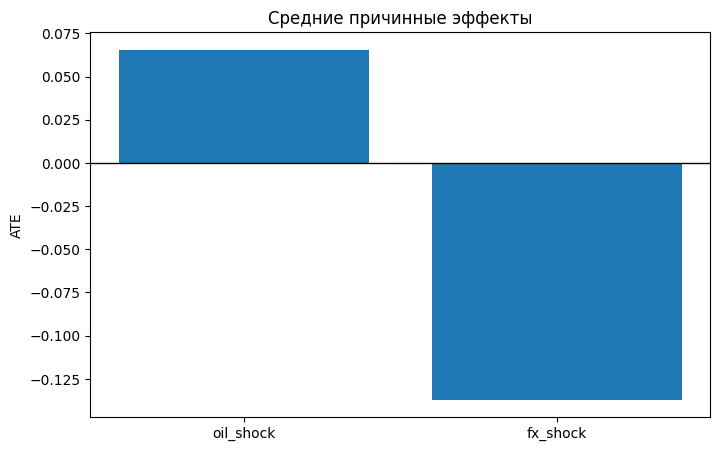

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results["effect"], results["ATE"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Средние причинные эффекты")
plt.ylabel("ATE")
plt.show()

Выводы:

- рост цен на нефть оказывает положительное влияние на доходность IMOEX;
- ослабление рубля оказывает отрицательное влияние на индекс;
- валютный фактор оказывает более сильное влияние, чем нефтяной;
- эффекты являются статистически значимыми;
- влияние факторов меняется во времени, что указывает на гетерогенность;
- результаты в целом сохраняются при изменении спецификации модели.

Таким образом, российский фондовый рынок существенно зависит от внешних макроэкономических факторов, прежде всего от динамики цен на нефть и валютного курса.

Сохранение результатов

In [ ]:
model_df.to_csv("imoex_causal_dataset.csv", index=True)
results.to_csv("imoex_main_results.csv", index=False)
period_results.to_csv("imoex_period_results.csv", index=False)
robust_results.to_csv("imoex_robust_results.csv", index=False)